In [1]:
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

In [2]:
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [3]:
print(text[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [5]:
# create mapping from characters to integers
stoi = { ch:i for i, ch in enumerate(chars) }
itos = { i:ch for i, ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder takes a string and converts to list of integers
decode = lambda l: ''.join([itos[e] for e in l]) # decoder takes a list of integers, output a string

print(encode('hello, world'))
print(decode(encode('hello, world')))

[46, 43, 50, 50, 53, 6, 1, 61, 53, 56, 50, 42]
hello, world


In [6]:
# let's encode the entire shakespeare dataset into a torch.tensor
import torch
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:100])

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59])


In [7]:
# split
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

In [8]:
block_size = 8
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [9]:
a = torch.tensor([1, 2, 3, 4])
b = torch.tensor([5, 6, 7, 8])

torch.stack([a, b], dim = 0)

tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])

In [10]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


## The mathematical trick in self-attention

- every token only talks to its past
- easiest way: averaging all the past tokens + the current token

In [11]:
torch.manual_seed(1337)
B,T,C = 4, 8, 2 # batch, time, channels
x = torch.randn(B,T,C)
x.shape 

torch.Size([4, 8, 2])

In [12]:
xbow = torch.zeros_like(x)
for b in range(B):
    for t in range(T):
        xprev = x[b, :t+1] # t, C
        xbow[b, t] = x[b, :t+1].mean(dim=0, keepdim=True)
        
xbow.shape

torch.Size([4, 8, 2])

In [13]:
x[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

In [14]:
xbow[0]

tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

### Three ways of calulcating the weighted some of the previous elements
--> attention

In [15]:
a = torch.tril(torch.ones(3, 3))
b = torch.randint(0, 10, (3, 2)).float()
a = a/a.sum(dim = 1, keepdim=True)
print(a)
print(b)
print(a @ b)

tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
tensor([[8., 6.],
        [5., 2.],
        [4., 4.]])
tensor([[8.0000, 6.0000],
        [6.5000, 4.0000],
        [5.6667, 4.0000]])


In [16]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0, 10, (3,2)).float()
c = a @ b
print('a=')
print(a)
print('----')
print('b=')
print(b)
print('----')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
----
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
----
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [17]:
# insight: you can do weighted aggregations of the past by using matrix multiplications
# with lower triangular matrices

In [18]:
import torch.nn.functional as F
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros(T, T)
wei = wei.masked_fill(tril == 0, float('-inf')) # the future cannot communicate with the past
wei = F.softmax(wei, dim=-1)
wei


tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [19]:
# 1)
# We want x[b, t] = mean_{i<=t} x[b, i]
xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] #(t,C)
        xbow[b,t] = torch.mean(xprev, 0)

In [20]:
# 2)
wei = torch.tril(torch.ones((T,T)))
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x # (B, T, T) @ (B, T, C) --> (B, T, C)
torch.allclose(xbow, xbow2)

True

In [30]:
print(xbow.shape)
print(x.shape)
print(wei.shape)

torch.Size([4, 8, 2])
torch.Size([4, 8, 2])
torch.Size([8, 8])


In [36]:
import torch.nn.functional as F
# 3) use Softmax
tril = torch.tril(torch.ones((T,T)), diagonal=0)
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ x


In [42]:
wei.shape
x.shape

torch.Size([4, 8, 2])

In [21]:
wei.var()

tensor(0.0273)

In [84]:
x = torch.randint(0, 10, (3, 3, 2)).float()
y = torch.randint(0, 10, (3, 3, 2)).float()
print('x =')
print(x)
print('y =')
print(y)
print('cat along channels')
print('=')
print(torch.cat([x, y], dim=-1))

x =
tensor([[[9., 2.],
         [2., 6.],
         [1., 6.]],

        [[0., 4.],
         [3., 3.],
         [3., 4.]],

        [[5., 9.],
         [7., 9.],
         [9., 7.]]])
y =
tensor([[[5., 6.],
         [5., 5.],
         [0., 8.]],

        [[8., 1.],
         [2., 8.],
         [7., 4.]],

        [[4., 7.],
         [5., 1.],
         [6., 9.]]])
cat along channels
=
tensor([[[9., 2., 5., 6.],
         [2., 6., 5., 5.],
         [1., 6., 0., 8.]],

        [[0., 4., 8., 1.],
         [3., 3., 2., 8.],
         [3., 4., 7., 4.]],

        [[5., 9., 4., 7.],
         [7., 9., 5., 1.],
         [9., 7., 6., 9.]]])


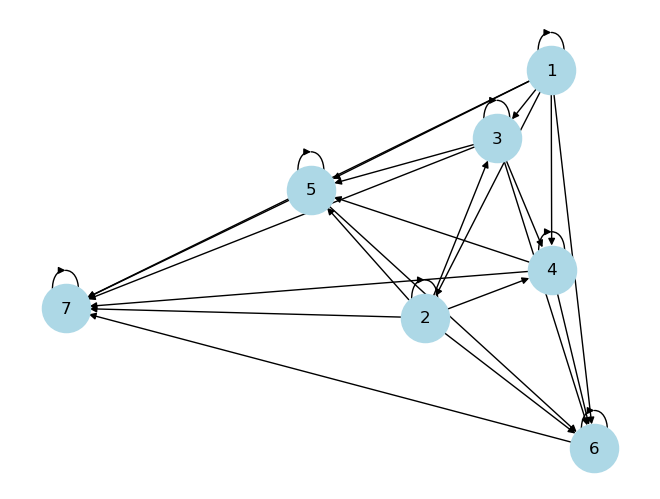

In [64]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Define the context size
context_size = 7

# Add nodes
for i in range(1, context_size+1):
    G.add_node(i)

# Add edges to represent the autoregressive nature of self-attention
for i in range(1, context_size+1):
    for j in range(1, i+1):
        G.add_edge(j, i)

# Draw the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1200, arrows=True)

# Show the plot
plt.show()


In [23]:
head_size = 16
k = torch.randn(B, T, head_size)
q = torch.randn(B, T, head_size)
wei = q @ k.transpose(-2, -1) * (1.0 / head_size) ** 0.5

# variance of wei
wei.var()
#q.var()
#k.var()

tensor(16.1906)

In [24]:
from torch import nn

# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)
head_size = 16
key = nn.Linear(C, 16, bias=False)
query = nn.Linear(C, 16, bias=False)
value = nn.Linear(C, 16, bias=False)
k = key(x) # (B, T, 16)
q = query(x) # (B, T, 16)
v = value(x) # (B, T, 16)
wei = k @ q.transpose(-2, -1)  # (B, T, 16) @ (B, 16, T) ---> (B, T, T) T square matrix giving us the affinities
# wei is now a function, in a data-dependent manner, between the keys and queries of these tokens.

tril = torch.tril(torch.ones((T,T)), diagonal=0)
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ v # (B, T, 16)
xbow3[0]

tensor(1.9224, grad_fn=<VarBackward0>)

In [60]:
import math
math.exp(1)

2.718281828459045

In [122]:
from torch import nn

# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# single Head performing self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False) 
query = nn.Linear(C, head_size, bias=False)
# we don't aggregate tokens exactly
value = nn.Linear(C, head_size, bias=False)
k = key(x) # B,T,16
q = query(x) # B,T,16
v = value(x) # B,T,16
wei = q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T,T))
# wei = torch.zeros(T, T)
wei = wei.masked_fill(tril==0, float('-inf'))
wei = F.softmax(wei, dim=-1) # doing a simple average

v = value(x)
out = wei @ v
out.shape
# what's the problem that self-attention solves?
# collecting data from the past in a data-dependent way

# here's what I have: key
# here's what I find interesting: query
# if you find my interesting, this is what I communicate to you: v
# x keeps being 'private' information to the token

torch.Size([4, 8, 16])

In [120]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

In [84]:
# every single token will emit two vectors: a query and a key
# query vector: what am I looking for?
# key vector: what do I contain?
# how to get affinities between the tokens?
# dot product between keys and queries.
# my query dot products with all the keys of all the other tokens and that dot product becomes Wei
# if query and a certain key are aligned, they'll interact with a higher amount 
# and I will learn more about that specific token as opposed to any other token in the sequence

In [ ]:
# 